# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR

In [3]:
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [4]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [7]:
tt_set = pd.read_pickle("pickle_files/training_data_prt.pkl")

In [8]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [9]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 251240 entries, Line to PRT
dtypes: float64(4), int64(251235), object(1)
memory usage: 2.0+ GB


In [11]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,0,0,1,0,0,1,1,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [12]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,
s100,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [32]:
snps_loc= Final_data.drop(['MD', 'LL',	'LW', 'MD',	'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,2,0,2,0,0,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,0,2,2,0,2,0,0,0,0,1


In [33]:
snps_all= Final_data.drop(['MD', 'PRT'], axis=1)
snps_all.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52267177,Chr20_52267897,Chr20_52270629,BBD,LL,LW,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,61.0,9.5000,6.26667,154.700,1,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,2,0,0,37.0,10.2200,7.19333,130.000,0,1,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,77.0,10.3667,7.76667,111.733,1,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,42.0,11.8200,7.78667,73.000,0,1,0
s101,0,0,1,0,0,1,1,0,0,0,...,2,0,0,62.0,14.2800,10.22000,95.700,0,0,1


In [ ]:
# Split training set into training and validation

In [52]:
X_train, X_test, y_train, y_test = train_test_split(snps, prt, test_size=0.2, random_state=42)

In [142]:
xgbreg = xgb.XGBRegressor(n_jobs =-1 , gamma= 1.0, learning_rate = 0.1, max_depth=7, n_estimators= 200)

In [143]:
xgbreg.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=1.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=None, ...)

In [144]:
y_pred_xgboost = xgbreg.predict(X_test)

In [145]:
r2_score(y_test, y_pred_xgboost)

-0.15247130393981934

In [146]:
mse = mean_squared_error(y_test, y_pred_xgboost)

In [147]:
rmse = np.sqrt(mse)
print(rmse)

26.116685046019313


# Define all functions

In [15]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}


In [16]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [17]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [18]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [19]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [20]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [21]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [34]:
#Load file
genotype = pd.read_csv('../gwas_prt/top_15percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 37685 entries, 0 to 37684
dtypes: int64(37685)
memory usage: 200.1 MB


In [35]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,37675,37676,37677,37678,37679,37680,37681,37682,37683,37684
0,0,0,1,2,0,0,0,0,1,0,...,2,2,0,2,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
2,2,0,2,1,1,0,0,0,1,0,...,2,1,0,2,0,0,0,0,0,0
3,3,0,2,1,1,0,0,0,1,0,...,0,2,0,2,0,0,0,1,0,0
4,4,0,1,1,1,0,0,0,0,0,...,0,2,0,2,0,1,1,0,0,0


In [36]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,37675,37676,37677,37678,37679,37680,37681,37682,37683,37684
0,,,,,,,,,,,,,,,,,,,,,
0,0,1,2,0,0,0,0,1,0,0,...,2,2,0,2,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1
2,0,2,1,1,0,0,0,1,0,0,...,2,1,0,2,0,0,0,0,0,0
3,0,2,1,1,0,0,0,1,0,1,...,0,2,0,2,0,0,0,1,0,0
4,0,1,1,1,0,0,0,0,0,1,...,0,2,0,2,0,1,1,0,0,0


In [37]:
column_names = pd.read_csv('../gwas_prt/id_names_top15.txt', sep=' ', header=None)

In [38]:
column_names.head

<bound method NDFrame.head of                     0
0          Chr1_17750
1         Chr1_122144
2         Chr1_123617
3         Chr1_123751
4         Chr1_124784
...               ...
37679  Chr20_52224394
37680  Chr20_52225633
37681  Chr20_52241655
37682  Chr20_52251920
37683  Chr20_52270629

[37684 rows x 1 columns]>

In [39]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 0 to 695
Columns: 37684 entries, ('Chr1_17750',) to ('Chr20_52270629',)
dtypes: int64(37684)
memory usage: 200.1 MB


In [40]:
genotype.head()

,"(Chr1_17750,)","(Chr1_122144,)","(Chr1_123617,)","(Chr1_123751,)","(Chr1_124784,)","(Chr1_130043,)","(Chr1_131374,)","(Chr1_132416,)","(Chr1_132473,)","(Chr1_133228,)",...,"(Chr20_51977670,)","(Chr20_51985385,)","(Chr20_52010114,)","(Chr20_52063297,)","(Chr20_52223472,)","(Chr20_52224394,)","(Chr20_52225633,)","(Chr20_52241655,)","(Chr20_52251920,)","(Chr20_52270629,)"
0,,,,,,,,,,,,,,,,,,,,,
0,0,1,2,0,0,0,0,1,0,0,...,2,2,0,2,0,0,0,0,0,0
1,0,1,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1
2,0,2,1,1,0,0,0,1,0,0,...,2,1,0,2,0,0,0,0,0,0
3,0,2,1,1,0,0,0,1,0,1,...,0,2,0,2,0,0,0,1,0,0
4,0,1,1,1,0,0,0,0,0,1,...,0,2,0,2,0,1,1,0,0,0


In [41]:
#Adding row names
rows= pd.read_csv('../gwas_prt/top_15percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [42]:
genotype.index = rows
genotype.head()

,"(Chr1_17750,)","(Chr1_122144,)","(Chr1_123617,)","(Chr1_123751,)","(Chr1_124784,)","(Chr1_130043,)","(Chr1_131374,)","(Chr1_132416,)","(Chr1_132473,)","(Chr1_133228,)",...,"(Chr20_51977670,)","(Chr20_51985385,)","(Chr20_52010114,)","(Chr20_52063297,)","(Chr20_52223472,)","(Chr20_52224394,)","(Chr20_52225633,)","(Chr20_52241655,)","(Chr20_52251920,)","(Chr20_52270629,)"
"(s63,)",0,1,2,0,0,0,0,1,0,0,...,2,2,0,2,0,0,0,0,0,0
"(s64,)",0,1,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1
"(s66,)",0,2,1,1,0,0,0,1,0,0,...,2,1,0,2,0,0,0,0,0,0
"(s70,)",0,2,1,1,0,0,0,1,0,1,...,0,2,0,2,0,0,0,1,0,0
"(s71,)",0,1,1,1,0,0,0,0,0,1,...,0,2,0,2,0,1,1,0,0,0


In [43]:
genotype.to_csv('genotype_top15_percent_prt.txt', sep ='\t', index = True)

In [44]:
!sed 's/[,()\x27]//g'  genotype_top15_percent_prt.txt > genotype_top15_percent_prt_new.txt

In [45]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top15_percent_prt_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_17750,Chr1_122144,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_132473,...,Chr20_51977670,Chr20_51985385,Chr20_52010114,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52225633,Chr20_52241655,Chr20_52251920,Chr20_52270629
0,s63,0,1,2,0,0,0,0,1,0,...,2,2,0,2,0,0,0,0,0,0
1,s64,0,1,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
2,s66,0,2,1,1,0,0,0,1,0,...,2,1,0,2,0,0,0,0,0,0
3,s70,0,2,1,1,0,0,0,1,0,...,0,2,0,2,0,0,0,1,0,0
4,s71,0,1,1,1,0,0,0,0,0,...,0,2,0,2,0,1,1,0,0,0


In [46]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 37685 entries, Unnamed: 0 to Chr20_52270629
dtypes: int64(37684), object(1)
memory usage: 200.1+ MB


In [47]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_17750,Chr1_122144,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_132473,Chr1_133228,...,Chr20_51977670,Chr20_51985385,Chr20_52010114,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52225633,Chr20_52241655,Chr20_52251920,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,1,2,0,0,0,0,1,0,0,...,2,2,0,2,0,0,0,0,0,0
s64,0,1,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,1
s66,0,2,1,1,0,0,0,1,0,0,...,2,1,0,2,0,0,0,0,0,0
s70,0,2,1,1,0,0,0,1,0,1,...,0,2,0,2,0,0,0,1,0,0
s71,0,1,1,1,0,0,0,0,0,1,...,0,2,0,2,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2042,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
s2460,0,2,1,1,0,0,0,2,0,0,...,0,2,0,2,0,0,0,0,0,0
s2513,0,2,1,1,0,0,0,0,0,1,...,2,2,0,0,0,0,0,1,0,2


In [48]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BBD                1094 non-null   int64  
 1   LW                 1094 non-null   float64
 2   LL                 1094 non-null   float64
 3   PLH                1094 non-null   float64
 4   BeiJing_2013       1094 non-null   int64  
 5   HeNan_2014         1094 non-null   int64  
 6   HeiLongJiang_2014  1094 non-null   int64  
 7   improved_cultivar  1094 non-null   int64  
 8   landrace           1094 non-null   int64  
 9   PRT                1094 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 94.0+ KB


In [49]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)
gwas_data.head()

,Line,Chr1_17750,Chr1_122144,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_132473,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
0,s100,0,2,1,1,1,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
1,s100,0,2,1,1,1,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
2,s101,0,0,0,0,0,0,0,0,1,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
3,s1014,0,0,0,1,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
4,s1014,0,0,0,1,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [50]:
gwas_data = gwas_data.set_index('Line')
gwas_data.head()

,Chr1_17750,Chr1_122144,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_132473,Chr1_133228,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,1,1,1,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,2,1,1,1,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,0,1,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,1,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,1,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [30]:
gwas_data= gwas_data.drop(['index'], axis=1)

KeyError: "['index'] not found in axis"

In [51]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 37694 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(37690)
memory usage: 314.6+ MB


In [52]:
gwas_data.head()

,Chr1_17750,Chr1_122144,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_132473,Chr1_133228,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,1,1,1,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,2,1,1,1,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,0,1,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,1,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,1,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


# GWAS all traits

In [6]:
#gwas_data.to_pickle("GWAS_top10percent_prt_data.pkl")
gwas_data = pd.read_pickle("pickle_files/GWAS_top10percent_prt_data.pkl")
gwas_data.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,1,1,1,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,1,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,1,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [7]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25133 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(25129)
memory usage: 209.8+ MB


In [8]:
gwas_y = gwas_data.iloc[:, 25132:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [17]:
gwas_all= gwas_data.drop(['PRT'], axis=1)
gwas_all.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [18]:
gwas_all_dupe= gwas_data.drop(['PRT'], axis=1)
gwas_all_dupe.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


# Run models

In [19]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [20]:
X_train.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,0,0,0,...,0,35,7.18000,9.62667,42.7000,0,1,0,1,0
s623,0,1,1,0,0,0,1,0,0,0,...,2,57,8.40000,9.20000,63.1000,1,0,0,1,0
s237,0,0,0,0,0,0,0,0,0,0,...,0,45,7.43333,10.36670,106.4670,1,0,0,1,0
s73,0,0,0,0,0,0,0,0,0,0,...,0,66,5.03333,7.73333,99.3333,1,0,0,1,0
s195,0,1,1,0,0,0,0,1,0,0,...,0,64,8.54667,13.18000,44.9400,0,0,1,1,0


In [21]:
X_train = X_train.to_numpy()

In [22]:
y_train = y_train.to_numpy()

In [23]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.01), ('colsample_bytree', 0.5260228416504515), ('gamma', 1e-09), ('learning_rate', 0.8761660690708175), ('max_delta_step', 1), ('max_depth', 49), ('min_child_weight', 10), ('n_estimators', 50), ('reg_alpha', 1.8928408077768074e-06), ('reg_lambda', 1000.0), ('subsample', 0.8902842730534833)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.01), ('colsample_bytree', 0.5260228416504515), ('gamma', 1e-09), ('learning_rate', 0.8761660690708175), ('max_delta_step', 1), ('max_depth', 49), ('min_child_weight', 10), ('n_estimators', 50), ('reg_alpha', 1.8928408077768074e-06), ('reg_lambda', 1000.0), ('subsample', 0.8902842730534833)])

In [24]:
gwas_all = gwas_all.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.001744202003222
RMSE for dataset is:19.26842691894515& mean of this fold is 350.4091
this is 5.49883747852015% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.3616265101887137
RMSE for dataset is:23.06497615497314& mean of this fold is 353.95564545454545
this is 6.516346455034891% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.1467957260266504
RMSE for dataset is:21.79091645496456& mean of this fold is 354.5901181818181
this is 6.145381762666928% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.7923892965647616
RMSE for dataset is:21.788896485042276& mean of this fold is 356.54790909090906
this is 6.111071171500479% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.474593542741013
RMSE for dataset is:20

In [25]:
pickle.dump(best_xgbr_model, open("gwas_top10_allfeats_xgbr_prt.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_allfeats_xgbr_bbd.pickle.dat", "rb"))

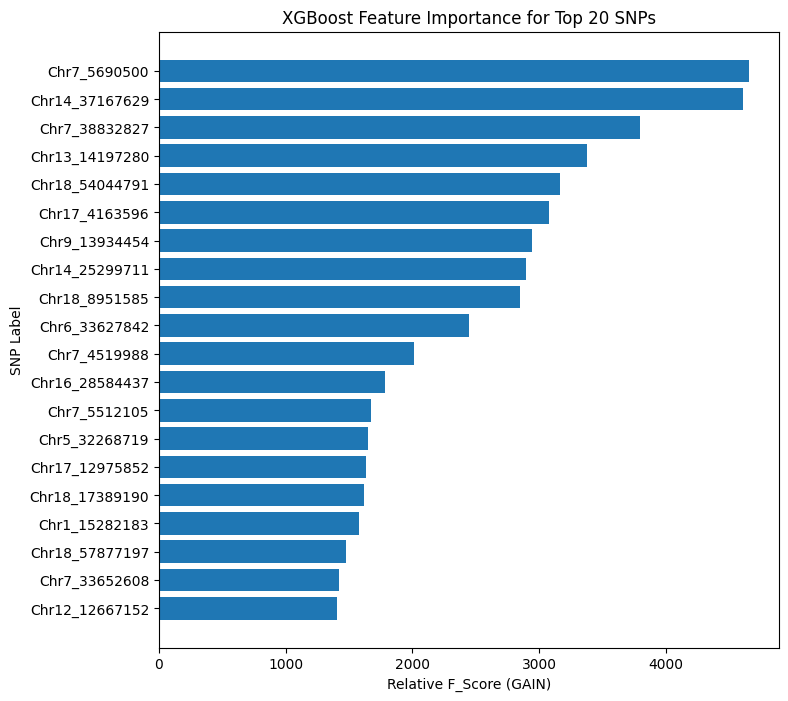

In [26]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_all_dupe, top_n=20)

In [27]:
explainer = shap.Explainer(best_xgbr_model)

In [28]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

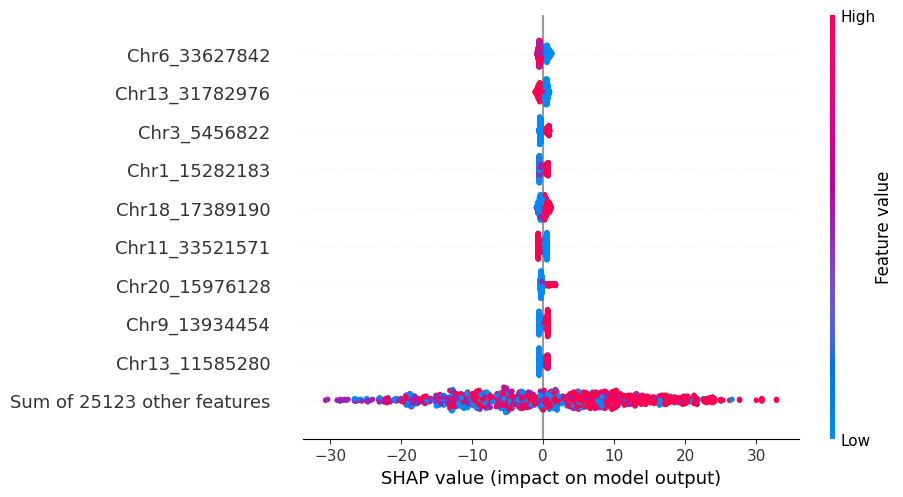

In [29]:
shap.plots.beeswarm(shap_values, show=False)

In [30]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [31]:
holdout_data = holdout_data.set_index('Line')

In [32]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [41]:
X_holdout = holdout_data.iloc[:, 0:251238]

In [42]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [43]:
y_holdout = holdout_data.iloc[:, 251238:]

In [44]:
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [45]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [46]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 25132 entries, Chr1_17750 to landrace
dtypes: float64(3), int64(25129)
memory usage: 52.5+ MB


In [47]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -4.00
RMSE of Holdout: 23.61
Mean of Holdout: 355.60
This is 6.64% of the mean pheno data
0 355.712 363.00317
1 344.136 355.5905
2 351.481 366.55658
3 353.611 372.23596
4 390.342 355.0752
5 358.958 352.78665


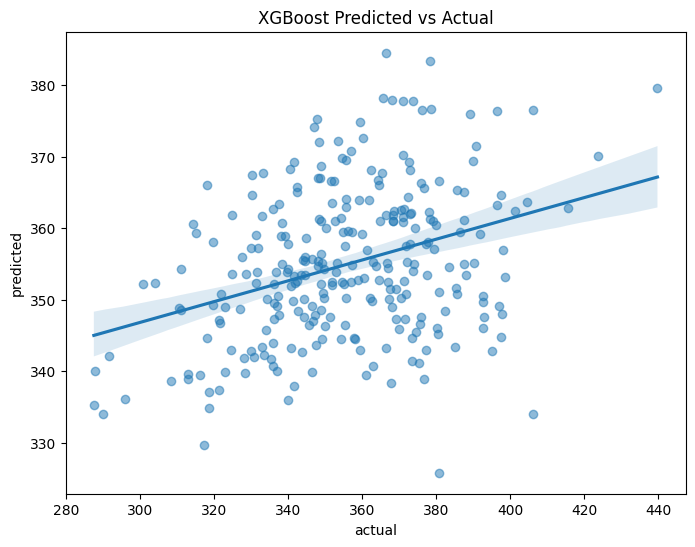

In [48]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [49]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 355.712 363.00317
1 344.136 355.5905
2 351.481 366.55658
3 353.611 372.23596
4 390.342 355.0752
5 358.958 352.78665


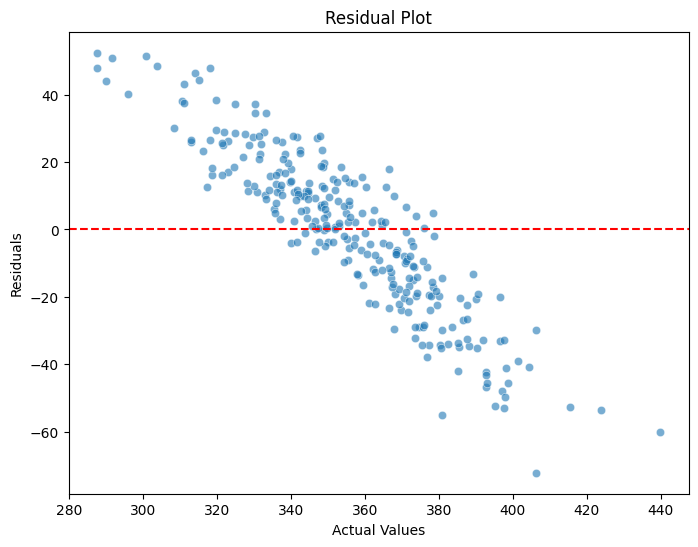

In [50]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [51]:
#### RF models

In [52]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 451)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 451)])

In [53]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.7643778197991304
RMSE for dataset is:19.649353090178803& mean of this fold is 350.2202272727273
this is 5.610570595306378% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.5022164684245
RMSE for dataset is:22.525688392316447& mean of this fold is 352.68345454545454
this is 6.386942200435232% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.5023987785064365
RMSE for dataset is:23.291323873908187& mean of this fold is 353.47538181818175
this is 6.589235084520998% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.474430119414722
RMSE for dataset is:21.731330085383405& mean of this fold is 356.21428181818175
this is 6.100634139221704% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.846667768643764
RMSE for da

In [54]:
pickle.dump(best_rfr_model, open("gwas_top10_allfeats_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -5.15
RMSE of Holdout: 23.51
Mean of Holdout: 355.60
This is 6.61% of the mean pheno data
0 355.712 363.320828232335
1 344.136 353.57870276141506
2 351.481 361.55053280355946
3 353.611 365.82480445678476
4 390.342 356.5674310170569
5 358.958 355.073607308025


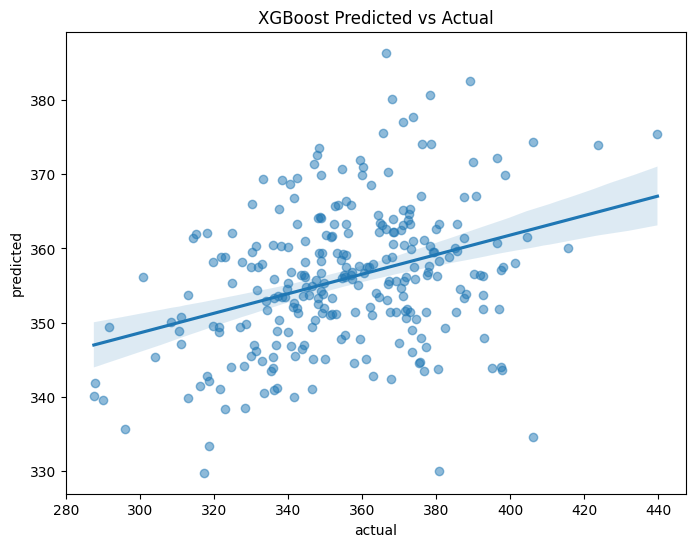

In [55]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [56]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [57]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5010368895966368
RMSE for dataset is:23.50180854206352& mean of this fold is 355.9357454545454
this is 6.602823358483058% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.11310360628548599
RMSE for dataset is:25.083729487438745& mean of this fold is 354.0373
this is 7.085052757841827% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.022851075273583987
RMSE for dataset is:25.293420871694337& mean of this fold is 356.3799272727273
this is 7.097319163079018% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.010865432460082758
RMSE for dataset is:20.889626263061782& mean of this fold is 354.293390909091
this is 5.896137720622032% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6342200807804887
RMSE for datase

In [58]:
pickle.dump(best_svr_model, open("gwas_top10_allfeats_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.76
RMSE of Holdout: 27.32
Mean of Holdout: 355.60
This is 7.68% of the mean pheno data
0 355.712 383.6786088911217
1 344.136 348.6240366975694
2 351.481 369.4480303933565
3 353.611 370.04266623530975
4 390.342 349.40594071957867
5 358.958 359.6632303416359


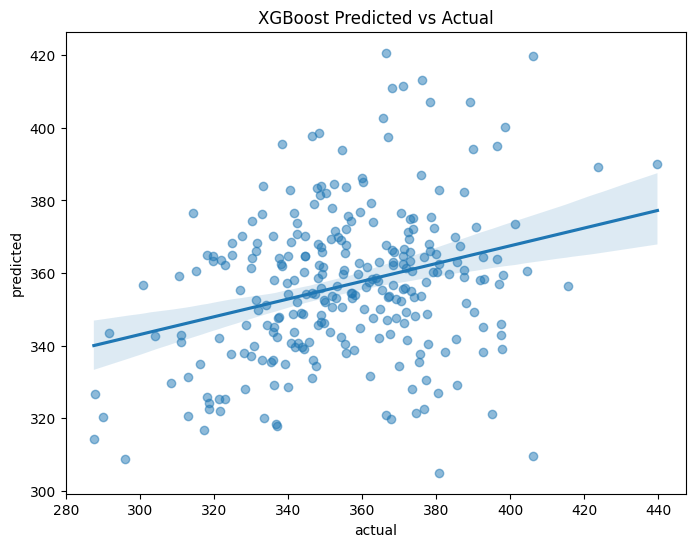

In [59]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [9]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25133 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(25129)
memory usage: 209.8+ MB


In [10]:
gwas_snps = gwas_data.iloc[:, 0:25123]
gwas_snps.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_51886171,Chr20_51888913,Chr20_51888995,Chr20_51890470,Chr20_51977670,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [11]:
gwas_snps_dupe = gwas_data.iloc[:, 0:25123]
gwas_snps_dupe.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_51886171,Chr20_51888913,Chr20_51888995,Chr20_51890470,Chr20_51977670,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s100,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
s1014,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [12]:
gwas_y = gwas_data.iloc[:, 25132:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


# Run models

In [36]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [37]:
X_train.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_51886171,Chr20_51888913,Chr20_51888995,Chr20_51890470,Chr20_51977670,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
s623,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,2,0,0,0,2
s237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
s73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,0
s195,0,1,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [69]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])

OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [70]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2883315729332776
RMSE for dataset is:22.961039983022882& mean of this fold is 351.8424454545454
this is 6.525943722724955% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6500311572873687
RMSE for dataset is:23.4934321083552& mean of this fold is 359.5732363636364
this is 6.53369876633318% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0567259211325948
RMSE for dataset is:22.07504366861455& mean of this fold is 354.41907272727275
this is 6.228514593965265% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.279918377591256
RMSE for dataset is:20.6879103422073& mean of this fold is 354.51531818181815
this is 5.835547656532352% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.1523525689680998
RMSE for datas

In [13]:
#pickle.dump(best_xgbr_model, open("gwas_top10_onlysnps_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("gwas_top10_onlysnps_xgbr_prt.pickle.dat", "rb"))

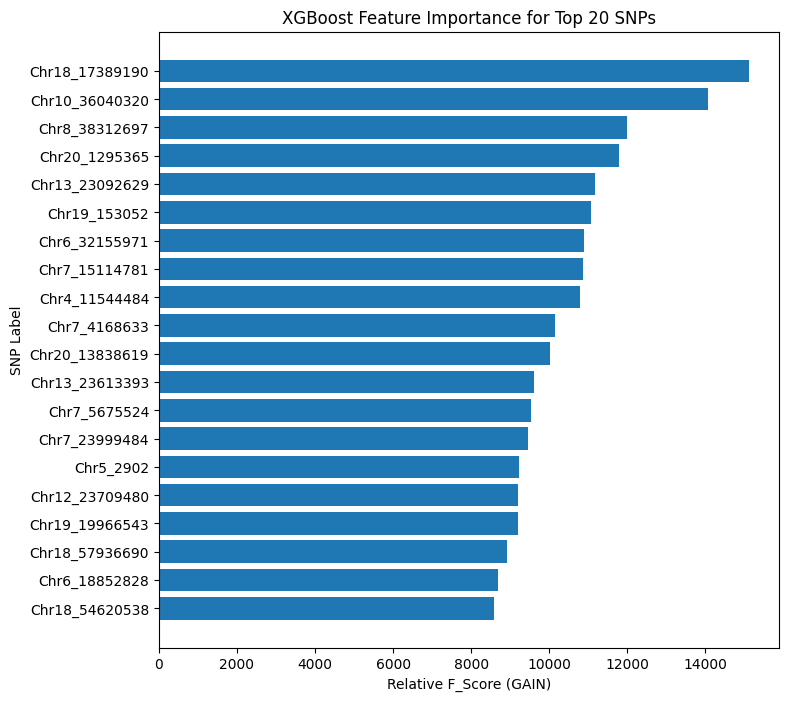

In [22]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_snps_dupe , top_n=20)

In [23]:
explainer = shap.Explainer(best_xgbr_model)

In [24]:
shap_values = explainer(gwas_snps_dupe)

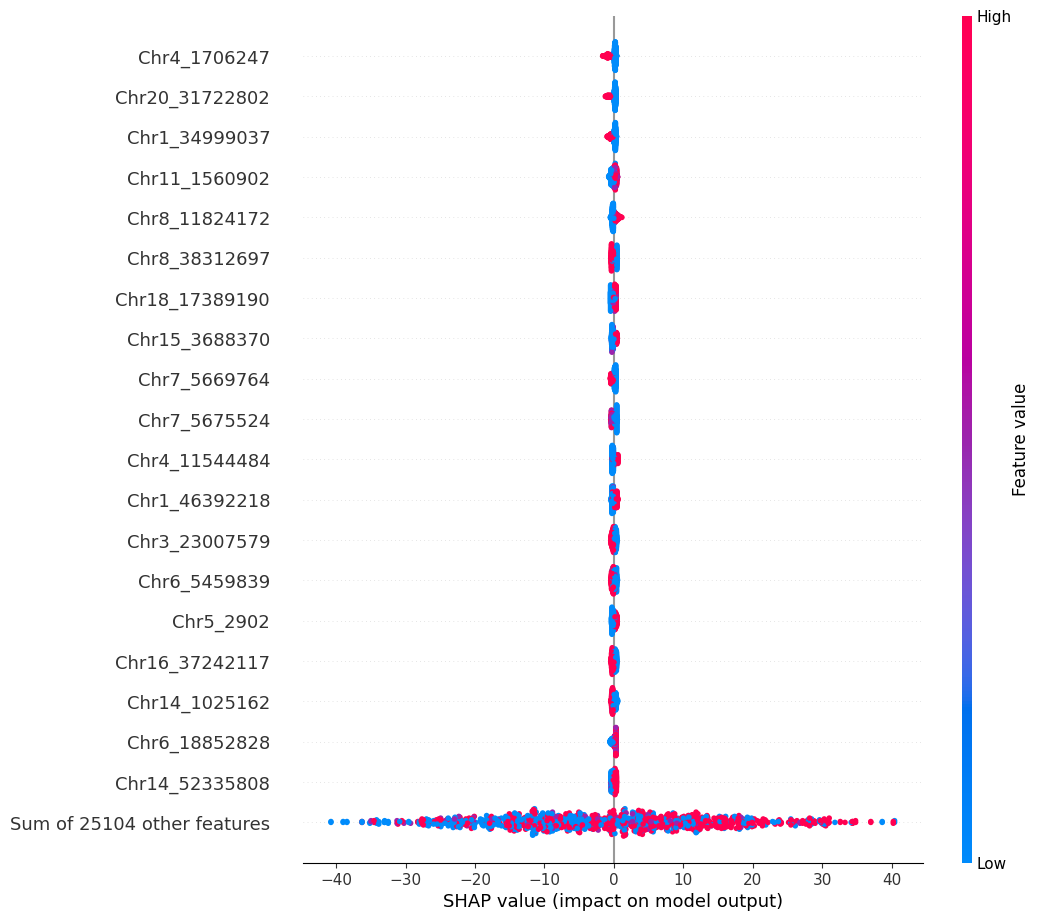

In [25]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [26]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [27]:
holdout_data = holdout_data.set_index('Line')

In [28]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [29]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [30]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [31]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 25123 entries, Chr1_17750 to Chr20_52270629
dtypes: int64(25123)
memory usage: 52.5+ MB


In [32]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -2.14
RMSE of Holdout: 24.72
Mean of Holdout: 355.60
This is 6.95% of the mean pheno data
0 355.712 361.26227
1 344.136 352.06586
2 351.481 367.04114
3 353.611 376.79108
4 390.342 347.48196
5 358.958 355.15506


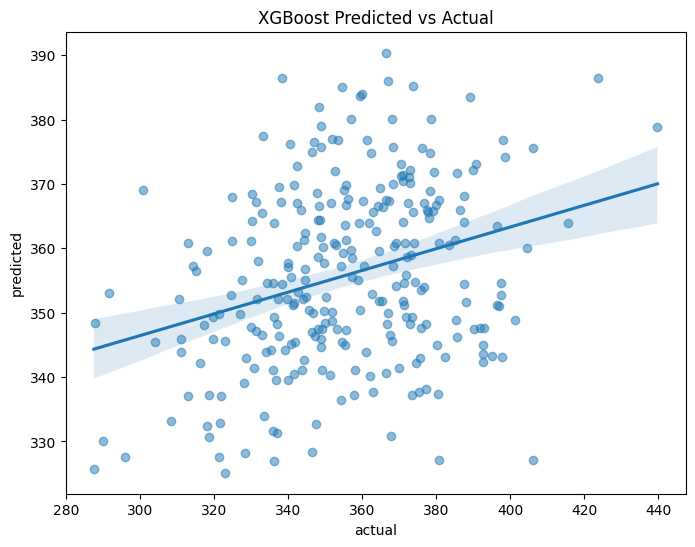

In [33]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [34]:
#### RF models

In [39]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 13), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 500)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 13), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 500)])

In [41]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.979697424701018
RMSE for dataset is:24.843044968084765& mean of this fold is 360.4797
this is 6.891662683941638% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.143891984660967
RMSE for dataset is:24.411734925330872& mean of this fold is 356.2531545454545
this is 6.852356144460797% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.587683669290245
RMSE for dataset is:21.021699166337747& mean of this fold is 355.9651181818181
this is 5.905550317320808% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.451420487510407
RMSE for dataset is:21.849596372455412& mean of this fold is 353.70286363636365
this is 6.1773874680637695% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.697299846047396
RMSE for dataset is:2

In [42]:
pickle.dump(best_rfr_model, open("gwas_top10_onlysnps_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.91
RMSE of Holdout: 23.37
Mean of Holdout: 355.60
This is 6.57% of the mean pheno data
0 355.712 363.6467150329939
1 344.136 354.3165323022087
2 351.481 360.7271244424489
3 353.611 365.82655140410503
4 390.342 357.0054511161063
5 358.958 355.66955847587775


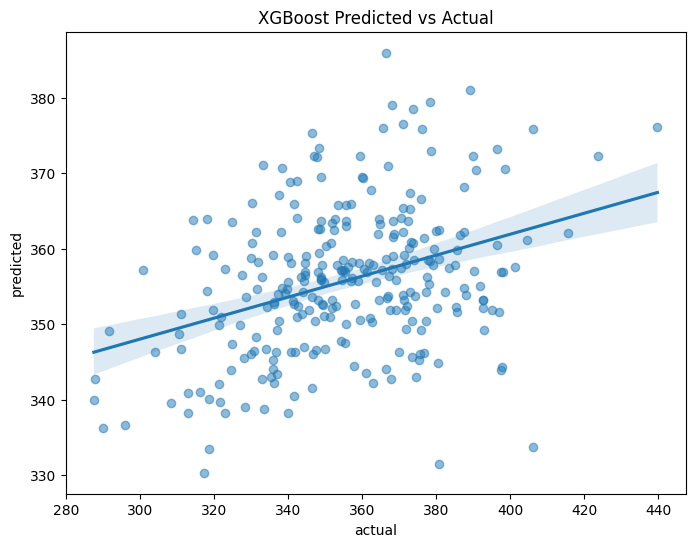

In [43]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [44]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [45]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.36777303254038496
RMSE for dataset is:21.80733190960302& mean of this fold is 356.91493636363634
this is 6.109952172857516% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5691312063488609
RMSE for dataset is:27.96479566420133& mean of this fold is 357.02940909090904
this is 7.832630856770894% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.22425817630128586
RMSE for dataset is:23.5092674312768& mean of this fold is 354.89711818181814
this is 6.624248613715909% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5859215806651703
RMSE for dataset is:26.56034252318039& mean of this fold is 354.44529090909094
this is 7.493495668981155% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.09020090571601225
RMSE fo

In [46]:
pickle.dump(best_svr_model, open("gwas_top10_onlysnps_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.89
RMSE of Holdout: 26.77
Mean of Holdout: 355.60
This is 7.53% of the mean pheno data
0 355.712 383.4149902136553
1 344.136 355.87208932552966
2 351.481 368.9779168796964
3 353.611 372.1593638326035
4 390.342 348.673766010285
5 358.958 364.58321330264346


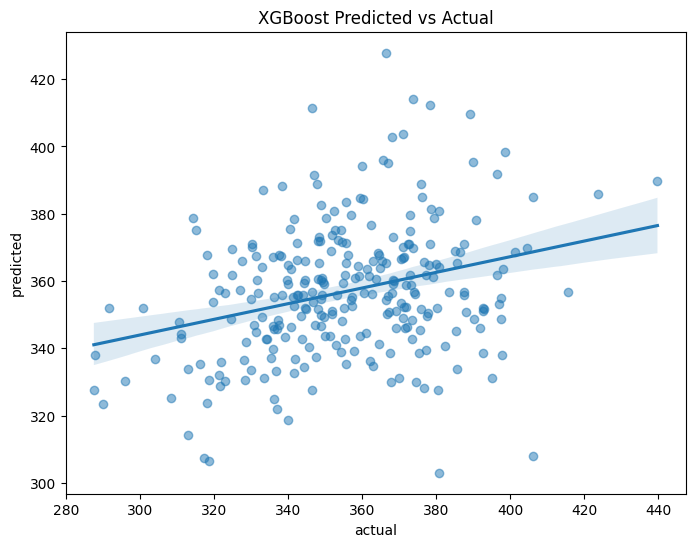

In [47]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [48]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
gwas_loc.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1


In [50]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
gwas_loc_dupe.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s100,0,1,1,1,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,1,0,0,0,0,0,0,0,...,2,0,0,0,0,0,1,0,0,1


In [51]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 25128 entries, Chr1_17750 to landrace
dtypes: int64(25128)
memory usage: 209.8+ MB


In [54]:
gwas_y = gwas_data.iloc[:, 25132:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [55]:
# Run models

In [56]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [57]:
X_train.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
s623,0,1,1,0,0,0,1,0,0,0,...,2,0,0,0,2,1,0,0,1,0
s237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
s73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,1,0,0,1,0
s195,0,1,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0


In [58]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [59]:
print(y_train[~np.isfinite(y_train)])

[]


In [60]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.01), ('colsample_bytree', 0.6086369388701954), ('gamma', 0.49999999999999994), ('learning_rate', 0.45615446227085915), ('max_delta_step', 2), ('max_depth', 0), ('min_child_weight', 2), ('n_estimators', 200), ('reg_alpha', 2.4524065685465204e-08), ('reg_lambda', 1000.0), ('subsample', 0.2519493637469424)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.01), ('colsample_bytree', 0.6086369388701954), ('gamma', 0.49999999999999994), ('learning_rate', 0.45615446227085915), ('max_delta_step', 2), ('max_depth', 0), ('min_child_weight', 2), ('n_estimators', 200), ('reg_alpha', 2.4524065685465204e-08), ('reg_lambda', 1000.0), ('subsample', 0.2519493637469424)])

OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [62]:
gwas_loc = gwas_loc.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.81990180769671
RMSE for dataset is:25.793727264457242& mean of this fold is 356.46736363636364
this is 7.235929539616903% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.828360628421032
RMSE for dataset is:20.63427168019356& mean of this fold is 348.7126454545454
this is 5.9172708386576796% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.9794121634463124
RMSE for dataset is:18.110005295732563& mean of this fold is 350.7852727272726
this is 5.1627039969299595% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.16376830939317
RMSE for dataset is:23.502896624246628& mean of this fold is 358.84201818181816
this is 6.54965010600798% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.1461061243923014
RMSE for dat

In [63]:
pickle.dump(best_xgbr_model, open("gwas_top10_onlyloc_xgbr_prt.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_onlyloc_xgbr_bbd.pickle.dat", "rb"))

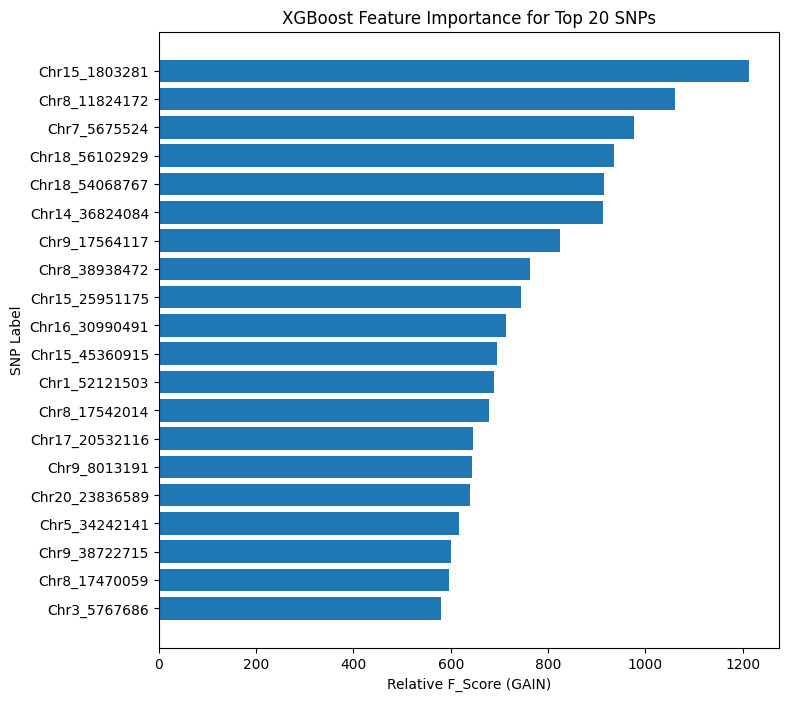

In [64]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_loc_dupe, top_n=20)

In [65]:
explainer = shap.Explainer(best_xgbr_model)

In [66]:
shap_values = explainer(gwas_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

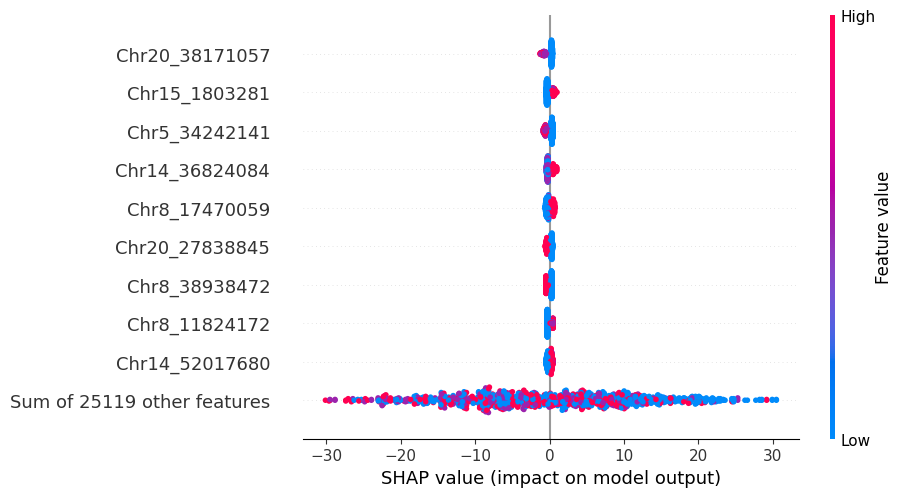

In [67]:
shap.plots.beeswarm(shap_values, show=False)

In [68]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [69]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [70]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [72]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [73]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc_dupe, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [74]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 25128 entries, Chr1_17750 to landrace
dtypes: int64(25128)
memory usage: 52.5+ MB


In [75]:
X_holdout.head()

,Chr1_17750,Chr1_123617,Chr1_123751,Chr1_124784,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_133228,Chr1_213719,Chr1_213749,...,Chr20_52063297,Chr20_52223472,Chr20_52224394,Chr20_52241655,Chr20_52270629,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s102,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s110,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
s112,0,0,0,0,0,0,1,2,0,0,...,2,0,0,0,0,1,0,0,0,1
s113,0,0,0,1,0,1,0,0,0,0,...,2,0,0,0,0,1,0,0,0,1


In [76]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -3.85
RMSE of Holdout: 23.55
Mean of Holdout: 355.60
This is 6.62% of the mean pheno data
0 355.712 357.88895
1 344.136 355.32037
2 351.481 360.86432
3 353.611 370.67752
4 390.342 356.0073
5 358.958 357.21158


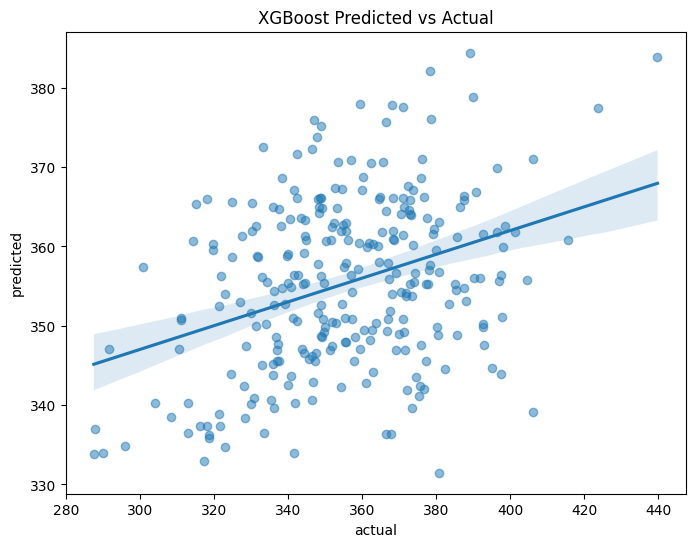

In [77]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [78]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 355.712 357.88895
1 344.136 355.32037
2 351.481 360.86432
3 353.611 370.67752
4 390.342 356.0073
5 358.958 357.21158


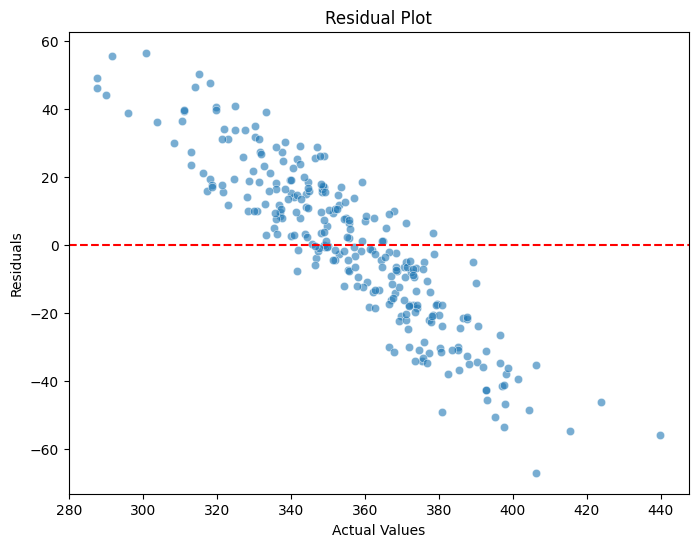

In [79]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [81]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.9357166827241417), ('min_samples_leaf', 4), ('min_samples_split', 3), ('n_estimators', 213)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.9357166827241417), ('min_samples_leaf', 4), ('min_samples_split', 3), ('n_estimators', 213)])

In [82]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.489753338043606
RMSE for dataset is:23.96230011512747& mean of this fold is 355.27489999999995
this is 6.744720810596941% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.9215110649067677
RMSE for dataset is:23.490080902304975& mean of this fold is 353.4387181818181
this is 6.646153829196795% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.710179362623408
RMSE for dataset is:21.44632140813537& mean of this fold is 352.8725090909091
this is 6.0776401832454% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.212534154738095
RMSE for dataset is:21.112563104945306& mean of this fold is 354.20908181818186
this is 5.960480458765464% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.0504308562794593
RMSE for datas

In [83]:
pickle.dump(best_rfr_model, open("gwas_top10_onlyloc_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -3.90
RMSE of Holdout: 23.37
Mean of Holdout: 355.60
This is 6.57% of the mean pheno data
0 355.712 367.8654695045826
1 344.136 355.68490356246684
2 351.481 362.42898857985415
3 353.611 368.26193105832493
4 390.342 355.8889187926575
5 358.958 355.20283176147655


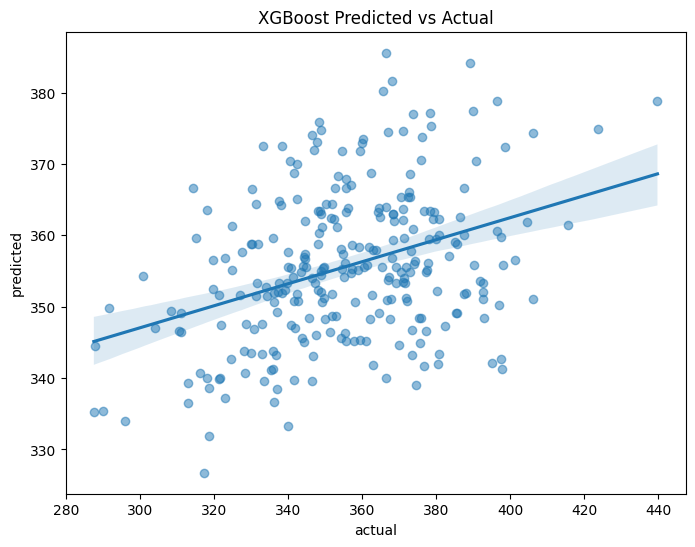

In [84]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [85]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [86]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.38122383163617335
RMSE for dataset is:25.156709630042798& mean of this fold is 357.355109090909
this is 7.039694967294585% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.36914525109770513
RMSE for dataset is:24.203872670328824& mean of this fold is 352.2215545454545
this is 6.871774983096696% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.3975690566580419
RMSE for dataset is:23.516588622792362& mean of this fold is 353.33518181818175
this is 6.655603470274711% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5328584776967735
RMSE for dataset is:23.44847619043257& mean of this fold is 351.97541818181816
this is 6.661964154076211% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.2570552939797186
RMSE fo

In [87]:
pickle.dump(best_svr_model, open("gwas_top10_onlyloc_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.78
RMSE of Holdout: 26.53
Mean of Holdout: 355.60
This is 7.46% of the mean pheno data
0 355.712 390.9411844788914
1 344.136 348.4407113634641
2 351.481 372.6508152538614
3 353.611 376.7122804362071
4 390.342 354.0756496907972
5 358.958 355.0693999625724


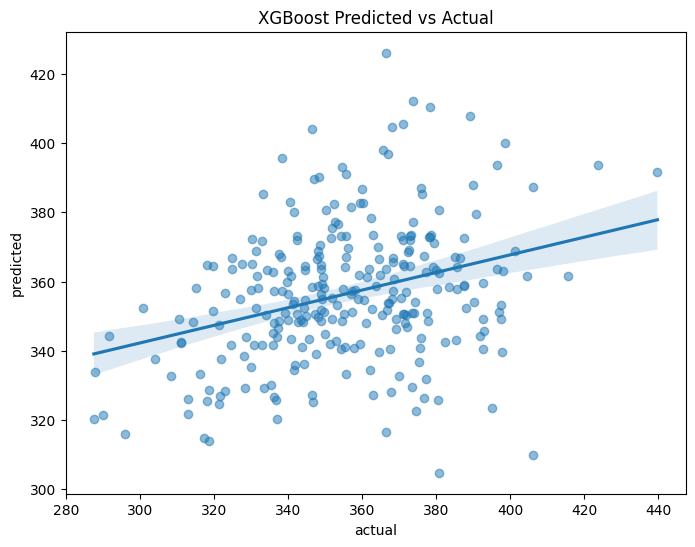

In [88]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)